In [90]:
print('Hello_World')

Hello_World


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

In [92]:
df = pd.read_csv('spam.csv', encoding='latin1')

# Data Understanding

In [93]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [94]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [95]:
df = df[['v1','v2']]

In [96]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [97]:
df.columns = ['label', 'message']

In [98]:
df.shape

(5572, 2)

# Data Preperation 
### 1.Removed unnecessary columns
### 2.Checked for missing values
### 3.Converted target labels into numeric format

In [99]:
df['label'] = df['label'].map({'ham':0 , 'spam':1}) 

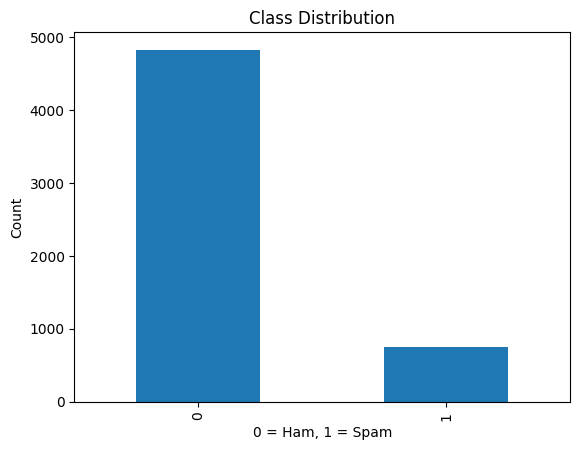

In [104]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.xlabel('0 = Ham, 1 = Spam')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [105]:
df['length'] = df['message'].apply(len)
df.groupby('label')['length'].mean()

label
0     71.023627
1    138.866131
Name: length, dtype: float64

In [100]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Train_Test Split

In [101]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(df['message'],
                                                 df['label'],
                                                 test_size=0.2,
                                                 random_state=42)

#### We convert text data into numerical form using TF-IDF Vectorization.

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [103]:
import itertools

my_dict = tfidf.vocabulary_

sliced_dict = dict(itertools.islice(my_dict.items(), 3))
print(sliced_dict)

{'boat': 1371, 'moms': 4416, 'check': 1706}


# Model Selection : Multinomial Naive Bayes....

In [109]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()
nb.fit(X_train_tfidf, Y_train)

Y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(Y_test, Y_pred_nb))
print(classification_report(Y_test, Y_pred_nb))

Naive Bayes Accuracy: 0.9668161434977578
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



# Predictions

In [112]:
def predict_spam(message):
    message_tfidf = tfidf.transform([message])
    result = nb.predict(message_tfidf)
    return "Spam" if result[0] == 1 else "Ham"

predict_spam("Congratulations! You have won a free prize")

'Spam'

In [113]:
predict_spam("Hello just want to have a chat with you")

'Ham'